### importing libraries

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

### reading the csv

In [33]:
df=pd.read_csv('Salary_Data.csv')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [ ]:
print(len(df['Salary']))   #to check the no of the rows in a column

30


### checking the correlation metrix

In [35]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [36]:
X=df[['YearsExperience']]
y=df['Salary']

In [37]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y, train_size=0.8,random_state=42)

### model evaluation

In [38]:
model=LinearRegression()

In [39]:
model.fit(Xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
ypred=model.predict(Xtest)

In [ ]:
error=ytest-ypred   # error= actual o/p - predicted o/p
error

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64

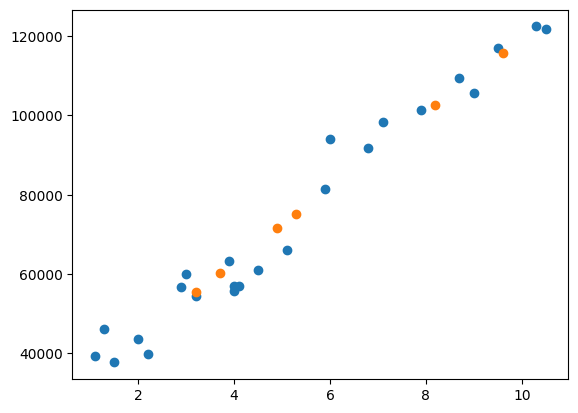

In [42]:
plt.scatter(Xtrain,ytrain)
plt.scatter(Xtest,ypred)
plt.show()

### regression line

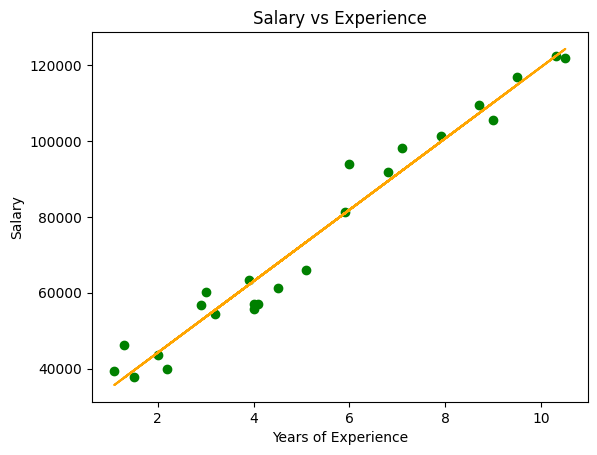

In [43]:
plt.scatter(Xtrain, ytrain, color='green')

plt.plot(Xtrain,
         model.predict(Xtrain),
         color='orange')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

In [49]:
print('mean_squared_error: ',mean_squared_error(ytest,ypred))
print('mean_absolute_error: ',mean_absolute_error(ytest,ypred))
print('root_mean_squared_error: ',root_mean_squared_error(ytest,ypred))
print('r2_score: ',r2_score(ytest,ypred))


mean_squared_error:  49830096.85590839
mean_absolute_error:  6286.453830757749
root_mean_squared_error:  7059.04362190151
r2_score:  0.9024461774180497


In [ ]:
# comparing the mae and rmse
'''MAE- 6286.45 
   RMSE- 7059.04
   
   7059.04 > 6286.45  (MAE> RMSE)
    
 '''

| Metric | Formula                          | Goal                             | Better Value         |
| ------ | -------------------------------- | -------------------------------- | -------------------- |
| MAE    | Average of |Actual − Predicted|  | Average prediction error         | Lower                |
| MSE    | Average of (Actual − Predicted)² | Penalizes large errors           | Lower                |
| RMSE   | √MSE                             | Error in original units          | Lower                |
| R²     | Goodness of fit                  | Explains how well the model fits | Higher (closer to 1) |


| R² Score | Meaning                                          |
| -------: | ------------------------------------------------ |
|      1.0 | Perfect prediction                               |
|     0.95 | Excellent                                        |
|     0.85 | Very Good                                        |
|     0.70 | Good                                             |
|     0.50 | Average                                          |
|        0 | No better than predicting the average every time |
| Negative | Very poor model                                  |
